# Section 0 - Import Tools

## 0.1. Import Packages

In [1]:
import pandas as pd
#from pandas.plotting import table
import numpy as np
import seaborn as sns
# import for auto-suggestions for objects
import pydot
import pyreadline
# import for sigmoid-fct.
import scipy
import scipy.special
from scipy import stats
from scipy.stats import gamma, truncnorm, describe
import sklearn
from sklearn import preprocessing, cluster
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
# import for plotting
import matplotlib.pyplot as plt
%matplotlib inline
import random
import time
import decimal
import json # to save history objects of keras models
import pickle # to save general objects, e.g. K-Means Clustering Object
import os

In [2]:
import tensorflow as tf
import keras
from keras import backend as K
from tensorflow.keras import layers
from keras.models import Sequential, Model, load_model
from keras.optimizers import Adam, SGD, Adadelta
from keras.layers import Dense, Flatten, Dropout, multiply, dot, Activation, ThresholdedReLU, RepeatVector, subtract, Reshape
from keras.layers import RNN, SimpleRNN,GRU, LSTM,CuDNNLSTM, Reshape, Lambda, InputLayer, Input, BatchNormalization, Average, average
from keras.layers import advanced_activations as adv_act
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping
from keras.utils import plot_model, print_summary
from keras.wrappers.scikit_learn import KerasClassifier, KerasRegressor
import seaborn as sb
import sobol_seq

Using TensorFlow backend.


## 0.2. Import customized functions

In [3]:
# Functions
%run functions/actuarial_functions.ipynb
%run functions/rnn_functions.ipynb
%run functions/visualization_functions.ipynb
%run functions/statistical_analysis_functions.ipynb
%run functions/clustering.ipynb

In [4]:
# Simulation of Data&Targets
%run Data/data_part1_simulation_feature_space.ipynb
%run Data/data_part2_calculation_targets.ipynb

In [5]:
# Data Preparation
%run Data/data_prep_General.ipynb
%run Data/data_prep_RNN_data_transformation.ipynb

In [6]:
# Single-dimensional data analysis
%run data_analysis_single_dimension/models_1dim_FFN.ipynb

In [7]:
len(list(range(40,68)))

28

# Section 1 - Global Parameters

In [8]:
# Makeham mortality model
A= 0.00022
B=2.7*10**(-6)
c=1.124

In [9]:
# Portfolio Details
N_contracts = 100000 
int_rate = 0.01
input_used = ['age_start', 'Sum_ins', 'duration', 'age_of_contract', 'interest_rate']
n_in = len(input_used)

In [10]:
# Standard values of features for projections
age_std = 40
sum_std = 100000
dur_std = 20
aoc_std = 0

In [11]:
Max_min = np.zeros([n_in,2])
age_low, age_up = 25, 67
sum_min, sum_max = 1000, 1000000
dur_min, dur_max = 2, 40
aoc_min, aoc_max = 0, dur_max-1
int_min, int_max = -0.01, 0.04 # 4% maximaler Rechnungszins
# zero-padded output/ length of later targets
n_output = dur_max +1

# Matrix Version of previous upper/ lower bounds on features
Max_min = np.array([age_low,age_up+dur_max,sum_min, sum_max, dur_min, dur_max, 
                    aoc_min, aoc_max, int_min, int_max]).reshape(n_in,2) #,dtype = 'int')

In [12]:
# Split ration training and test data
ratio_tr_tst = 0.7
N_train = int(ratio_tr_tst*N_contracts)

# share of validation data
val_share = 0.25

In [13]:
# current directory for saving issues
cd = r"C:\Users\mark.kiermayer\Documents\Promotion\Python Scripts\Paper (Grouping) - Code\TermLife"
# dummy if saved models should be loaded (TRUE) or the all models should be recalculated (False)
dummy_load_saved_models = True

# Dataframe representation
pd.set_option('precision', 2)

# Section 2 - Data

## 2.1. Simulation of feature variables

In [14]:
random.seed(42)
# data for full dimension
data = data_simulation_features(A, B, c, N_contracts, Max_min, N_features= n_in)

In [15]:
data.shape, data[30,:]

((100000, 5),
 array([2.90000e+01, 5.31718e+05, 1.70000e+01, 3.00000e+00, 1.34375e-02]))

In [16]:
data[:,0:4].astype('int')

array([[    56, 500500,     21,     10],
       [    63, 250750,     30,      7],
       [    43, 750250,     11,      7],
       ...,
       [    52, 342615,      7,      4],
       [    31, 842115,     26,      4],
       [    34, 108474,     14,      7]])

## 2.2. Calculation of Target Values

In [17]:
# Create Targets
targets = data_simulation_targets(data=data[:,0:4].astype('int'), dur_max= dur_max, A=A, B=B,c=c,
                                     int_rate= data[:,4] )

[ 5.90000e+01  8.12687e+05  3.20000e+01  5.00000e+00 -6.87500e-03]


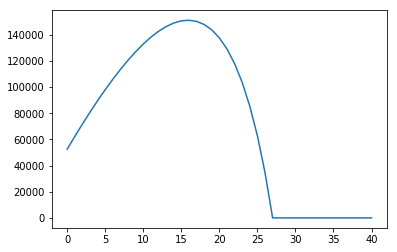

In [18]:
i=8
print(data[i,:])
plt.plot(targets[i,:])

In [19]:
(data[1:20,4])

array([ 0.0275   ,  0.0025   ,  0.03375  ,  0.00875  , -0.00375  ,
        0.02125  ,  0.018125 , -0.006875 ,  0.005625 ,  0.030625 ,
        0.011875 ,  0.036875 ,  0.024375 , -0.000625 ,  0.0040625,
        0.0290625,  0.0165625, -0.0084375,  0.0228125])

(785665.9694286799, 0.0)

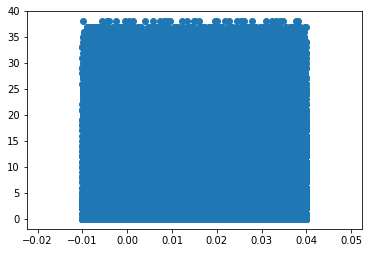

In [20]:
#plt.hist(data[:,4])
plt.scatter(data[:,4], data[:,3])
targets.max(), targets.min()

## 2.3. Data Preparation

### 2.3.1. Scaling

In [21]:
## Parameters for scaling procedure of targets
V_max  = get_termlife_reserve_profile(age_curr=age_up, Sum_ins = sum_max, duration=dur_max, interest = int_min).max() 
V_min = get_termlife_reserve_profile(age_curr=age_low, Sum_ins = sum_min, duration=dur_min, interest = int_max).min()

In [22]:
V_max, V_min

(847830.2414220588, 0.0)

In [23]:
## Scale feature components to [-1,+1]

## FFN
data_sc = data_prep_feautures_scale(data, Max_min, option = 'conditional')

In [24]:
data_sc

array([[-0.24390244,  0.        ,  0.        , -0.04761905,  0.        ],
       [-0.07317073, -0.5       ,  0.47368421, -0.53333333,  0.5       ],
       [-0.56097561,  0.5       , -0.52631579,  0.27272727, -0.5       ],
       ...,
       [-0.34146341, -0.31608609, -0.73684211,  0.14285714,  0.67985535],
       [-0.85365854,  0.68391391,  0.26315789, -0.69230769, -0.32014465],
       [-0.7804878 , -0.78483684, -0.36842105,  0.        ,  0.21110535]])

### 2.3.2. Split (raw and scaled) Data in Training and Test Set

#### 2.3.2.1. FFN

In [25]:
# Complete Data
data_train,data_test = data_prep_split(data,ratio_tr_tst)
data_train_sc, data_test_sc = data_prep_split(data_sc, ratio_tr_tst)
targets_train, targets_test= data_prep_split(targets,ratio_tr_tst)

## 2.4. Data Visualization and Analysis

### 2.4.1 Vizualize SUS Model

In [26]:
age_grid = np.linspace(start = 0, stop = 130, num = 131)
susm_val = 1-np.exp(-0.02-2.7*10**(-5)/np.log(1.1)*1.1**age_grid*(1.1-1))

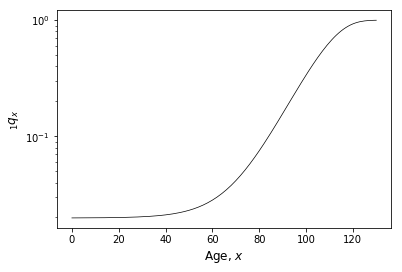

In [27]:
plt.plot(age_grid, susm_val, color = 'black', linewidth = 0.7)
plt.yscale('log')
plt.ylabel(r'${}_1 q_x$', fontsize = 'large')
plt.xlabel('Age, $x$', fontsize = 'large')
plt.show()
# Note: Comparison SUSM vs. Life Table is plotted in seperate R-file.

### 2.4.3. Visualize Simulated Data

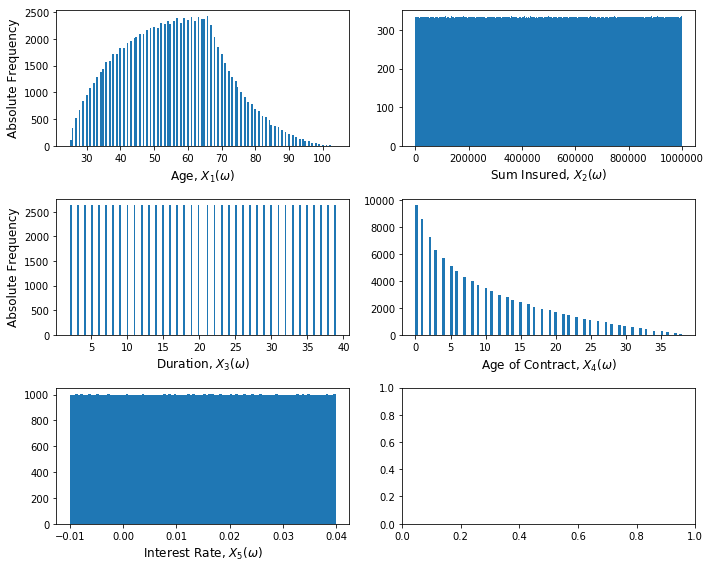

In [28]:
fig, ax = plt.subplots(3,2, figsize = (10,8))
ax = ax.flatten()
ax[0].hist(data[:,0], bins = 150 )#, density = True)
ax[0].set_xlabel('Age, $X_1(\omega)$', fontsize = 'large')
ax[0].set_ylabel('Absolute Frequency', fontsize = 'large')
ax[1].hist(data[:,1], bins = 300)#, density = True)
ax[1].set_xlabel('Sum Insured, $X_2(\omega)$', fontsize = 'large')
ax[2].hist(data[:,2], bins = 150)#, density = True)
ax[2].set_xlabel('Duration, $X_3(\omega)$', fontsize = 'large')
ax[2].set_ylabel('Absolute Frequency', fontsize = 'large')
ax[3].hist(data[:,3], bins = 100)#, density = True)
ax[3].set_xlabel('Age of Contract, $X_4(\omega)$', fontsize = 'large')
ax[4].hist(data[:,4], bins = 100)#, density = True)
ax[4].set_xlabel('Interest Rate, $X_5(\omega)$', fontsize = 'large')

plt.tight_layout()
plt.show()

### 2.4.4. Exemplary Profile of Policy Values

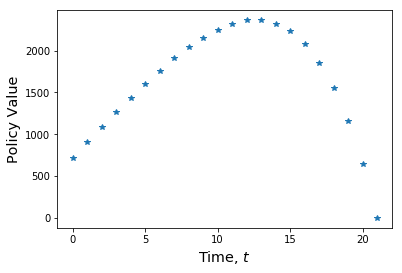

In [29]:
plt.plot(get_termlife_reserve_profile(age_curr = 49, Sum_ins = 100000, duration = 25, interest = 0.05, 
                                      age_of_contract= 4, option_past = False), '*')
         #color = 'black', linewidth = 0.7)
plt.ylabel('Policy Value', fontsize = 'x-large')
plt.xlabel('Time, $t$', fontsize = 'x-large')
plt.show()

### 2.4.5. Visualization - Range of Targets

In [30]:
# Tabular version of range of targets

df = pd.DataFrame(data= None, index = None, columns = ['25% percentile', 'median', '75% percentile', 'max.'])
df.loc['$\max_{t} Y(\omega)_t$']= [np.quantile(a = targets.max(axis=1), q=0.25),np.quantile(a = targets.max(axis=1), q=0.5),
                             np.quantile(a = targets.max(axis=1), q=0.75),targets.max()]

In [31]:
df

,25% percentile,median,75% percentile,max.
$\max_{t} Y(\omega)_t$,471.44,3870.6,23625.29,785665.97


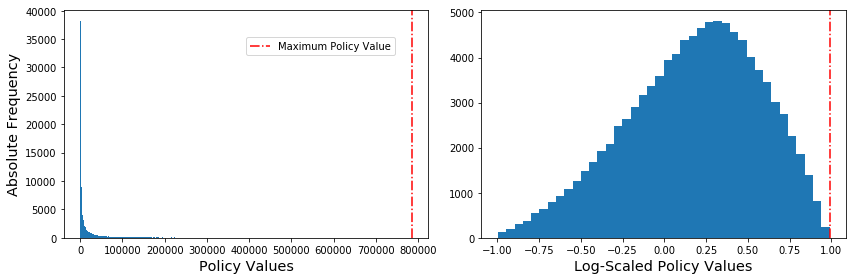

In [32]:
# Check Scaling feature of multivariate data

fig, [ax1, ax2] = plt.subplots(1,2, figsize = (12,4))
ax1.hist(targets.max(axis=1), bins = 500, density = False)
ax1.axvline(targets.max(axis=1).max(),color = 'red', linestyle = '-.', label = 'Maximum Policy Value')
ax1.legend(loc=(0.5,0.8))
ax1.set_ylabel('Absolute Frequency', fontsize = 'x-large')
ax1.set_xlabel('Policy Values', fontsize = 'x-large')
#ax1.set_title('Histogram of maximal reserves per contract')

ax2.hist(2*np.log(1+targets.max(axis=1))/np.log(1+V_max)-1, bins = 40, density=False)
ax2.axvline((np.log(1+targets.max(axis=1))/np.log(1+V_max)).max(),color = 'red', linestyle = '-.')
ax2.set_xlabel('Log-Scaled Policy Values', fontsize = 'x-large')

#ax2.set_title('Histogram of maximal reserves per contract on a log-scale')
plt.tight_layout()
plt.show()


# Section 3: Reserve Replication, Single Contract Basis

## 3.3. Recurrent Neural Networks

### 3.3.2. RNN - full-dimensional Input

In [33]:
# Parameters
N_epochs = 500 
batch_size = 64
n_timesteps, n_features, n_output = dur_max+1,n_in, dur_max+1
#INPUT = Input(shape=(n_timesteps,n_features), name = 'Input')
INPUT = Input(shape=(n_features,), name = 'Input')
#batchsize
wd_rnn = cd +r'\ipynb_Checkpoints\Prediction'

In [34]:
%run functions/rnn_functions.ipynb
%run functions/visualization_functions.ipynb
%run functions/statistical_analysis_functions.ipynb

In [35]:
es = EarlyStopping(monitor= 'val_loss', patience= 100 )

#### Model with RNN-Layers: 1, Final Dense Layer: 1, Scaling: Min-Max, Activation-Fct.: 'tanh' , Dropout: Yes, Scaling: 'log'

In [36]:
# Create Model
rnn = create_rnn_model(model_input=INPUT,widths_rnn= [2*n_output], widths_ffn=[n_output], 
                        optimizer_type='adam',loss_type='mse', 
                        metric_type='mae', dense_act_fct= 'tanh',
                        dropout_rnn=0.5, option_CUDA= True, option_recurrent_dropout= False,
                       n_repeat= 10,
                       lambda_layer = True, lambda_scale =V_max, log_scale=True)

# Either load existing parameters
if os.path.isfile(wd_rnn+r'\rnn_v0_weights.h5') & dummy_load_saved_models:
    # load model weights
    rnn.load_weights(wd_rnn+r'\rnn_v0_weights.h5')
    #load training history
    rnn_hist = json.loads(open(wd_rnn+r'\rnn_v0_hist.json', 'r').read())
    
# Or train model    
else:
    
    # Train Model
    rnn_hist = rnn.fit(data_train_sc, targets_train, batch_size=  64,epochs = N_epochs, 
                       validation_split=val_share, callbacks = [es])
    
    # Save Model weights
    rnn.save_weights(wd_rnn + r'\rnn_v0_weights.h5')
    
    # Make history object compatibel with .json format
    rnn_hist = rnn_hist.history
    # Save Training History
    with open(wd_rnn+r'\rnn_v0_hist.json', 'w') as f:
        json.dump(rnn_hist, f )

Instructions for updating:
Colocations handled automatically by placer.


In [37]:
rnn.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Input (InputLayer)           (None, 5)                 0         
_________________________________________________________________
repeat_vector_1 (RepeatVecto (None, 41, 5)             0         
_________________________________________________________________
RNN_1 (CuDNNLSTM)            (None, 82)                29192     
_________________________________________________________________
Dense_1 (Dense)              (None, 41)                3403      
_________________________________________________________________
tanh (Activation)            (None, 41)                0         
_________________________________________________________________
Log_Scaling_Layer (Lambda)   (None, 41)                0         
Total params: 32,595
Trainable params: 32,595
Non-trainable params: 0
_________________________________________________________________


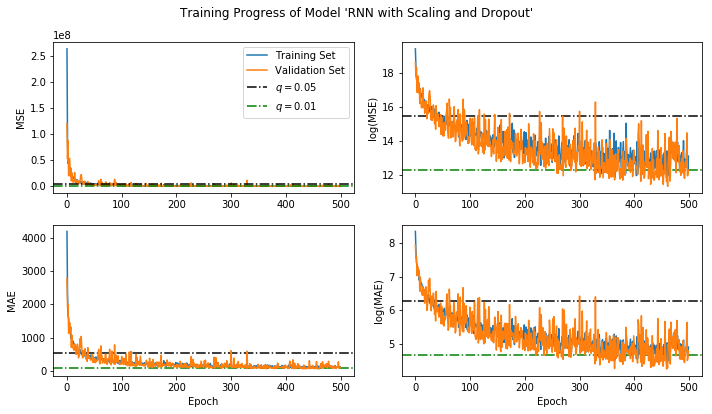

In [38]:
training_progress_visual(history= rnn_hist, y = targets_train, model_name= "'RNN with Scaling and Dropout'")

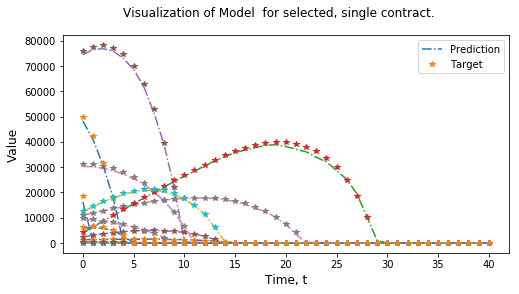

In [39]:
# Visualize Prediction Qualitiy on Test Data
visualize_prediction_quality(model=rnn, x=data_test_sc, y=targets_test, 
                             position = np.linspace(3050,3065,16).astype('int'))

#### Model with RNN-Layers: 1, Final Dense Layer: 1, Scaling: Min-Max, Activation-Fct.: 'linear' , Dropout: No, Scaling: 'log'

In [40]:
rnn_1 = create_rnn_model(model_input=INPUT,widths_rnn= [n_output], widths_ffn=[n_output], 
                        optimizer_type='adam',loss_type='mse', 
                        metric_type='mae', dense_act_fct= 'tanh',
                        dropout_rnn=0, option_CUDA= True, option_recurrent_dropout= False,
                       lambda_layer = True, lambda_scale =V_max, log_scale=True)

# Either load existing parameters
if os.path.isfile(wd_rnn+r'\rnn_v1_weights.h5') & dummy_load_saved_models:
    # load model weights
    rnn_1.load_weights(wd_rnn+r'\rnn_v1_weights.h5')
    #load training history
    rnn_1_hist = json.loads(open(wd_rnn+r'\rnn_v1_hist.json', 'r').read())
    
# Or train model    
else:
    
    # Train Model
    rnn_1_hist = rnn_1.fit(data_train_sc, targets_train, batch_size=  64,epochs = N_epochs, 
                       validation_split=val_share, callbacks = [es])
    
    # Save Model weights
    rnn_1.save_weights(wd_rnn + r'\rnn_v1_weights.h5')
    
    # Make history object compatibel with .json format
    rnn_1_hist = rnn_1_hist.history
    # Save Training History
    with open(wd_rnn+r'\rnn_v1_hist.json', 'w') as f:
        json.dump(rnn_1_hist, f )

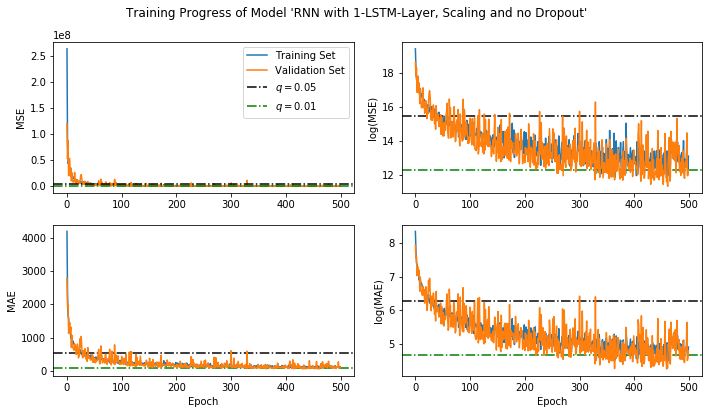

In [41]:
training_progress_visual(history= rnn_hist, y = targets_train, 
                         model_name= "'RNN with 1-LSTM-Layer, Scaling and no Dropout'")

In [42]:
rnn.evaluate(data_test_sc, targets_test)

30000/30000 [==============================] - 3s 84us/step


[214299.2402875, 122.25753607584636]

## 3.3. Ensemble Method for Quantitative Models

Here, we apply an ensemble method an use several models with equal configuration to predict the reserve of a contract by the models' average prediction.

Different Configurations will be compared in the section 3.5.2.

In [43]:
# General settings
BATCH = 64
N_epochs = 1500

es_patience = 100

In [44]:
## Train MSE Models

# Either load existing parameters
N_ensembles = 10


# Create Multiple RNNs with identical configuration
models_mse_hist = {}
models_mse = create_multiple_rnn_models(number=N_ensembles, model_input=INPUT,widths_rnn =[n_output], 
                                  widths_ffn = [n_output], 
                                   dense_act_fct = 'tanh', optimizer_type='adam', loss_type='mse', 
                                   metric_type='mae', dropout_share=0, 
                                   lambda_layer = True, lambda_scale =V_max, log_scale=True, 
                                    model_compile = True, return_option = 'model', branch_name = '')

if os.path.isfile(wd_rnn+r'\mse\model_0.h5') & dummy_load_saved_models:
    # load model weights
    for i in range(N_ensembles):
        models_mse[i].load_weights(wd_rnn+r'\mse\model_{}.h5'.format(i))
        with open(wd_rnn+r'\mse\model_{}_hist.json'.format(i), 'rb') as f:
            models_mse_hist[i] = pickle.load(f)
        
# Or train model    
else:
    # Train multiple RNNs with identical configuration
    models_mse, models_mse_hist = train_individual_ensembles(models_mse, data_train_sc, targets_train, 
                                                    n_epochs= N_epochs, 
                                                    n_batch= BATCH, es_patience= es_patience,
                                                    path = wd_rnn+r'\mse')
    # Save Model (and History) is integrated in function 'train_individual_ensembles'

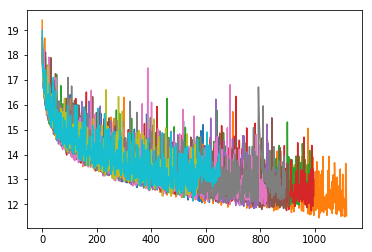

In [45]:
for i in range(10):
    plt.plot(np.log(models_mse_hist[i]['val_loss']))

In [46]:
## Train MAE Models

# Either load existing parameters
N_ensembles = 10


# Create Multiple RNNs with identical configuration
models_mae_hist = {}
models_mae = create_multiple_rnn_models(number=N_ensembles, model_input=INPUT,widths_rnn =[n_output], 
                                  widths_ffn = [n_output], 
                                   dense_act_fct = 'tanh', optimizer_type='adam', loss_type='mae', 
                                   metric_type='mae', dropout_share=0, 
                                   lambda_layer = True, lambda_scale =V_max, log_scale=True, 
                                    model_compile = True, return_option = 'model', branch_name = '')

if os.path.isfile(wd_rnn+r'\mae\model_0.h5') & dummy_load_saved_models:
    # load model weights
    for i in range(N_ensembles):
        models_mae[i].load_weights(wd_rnn+r'\mae\model_{}.h5'.format(i))
        with open(wd_rnn+r'\mae\model_{}_hist.json'.format(i), 'rb') as f:
            models_mae_hist[i] = pickle.load(f)
        
# Or train model    
else:
    # Train multiple RNNs with identical configuration
    models_mae, models_mae_hist = train_individual_ensembles(models_mae, data_train_sc, targets_train, 
                                                    n_epochs= N_epochs, 
                                                    n_batch= BATCH, es_patience= es_patience,
                                                    path = wd_rnn+r'\mae')
    # Save Model (and History) is integrated in function 'train_individual_ensembles'

In [47]:
for i in range(10):
    print(len(models_mae_hist[i]['val_loss']))

583
782
760
814
853
907
851
895
876
860


#### Ensembles: 5, Loss: MSE (V0)

In [48]:
# Fix Number of Ensembles used
N_ensembles = 5
N_epochs_ensemble = 1000
dummy_load_saved_models_ensembles = True
wd_ensembles = cd +r'\ipynb_Checkpoints\Ensembles'
batchsize = 128
es_patience = 100

In [49]:
%run functions/rnn_functions.ipynb
%run functions/visualization_functions.ipynb

In [50]:
# Either load existing parameters
N_ensembles = 5
    
# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mse_5 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mse[0:N_ensembles]), 
                                scale = V_max,
                               LSTM_nodes= [n_output], dense_act_fct= 'tanh')    

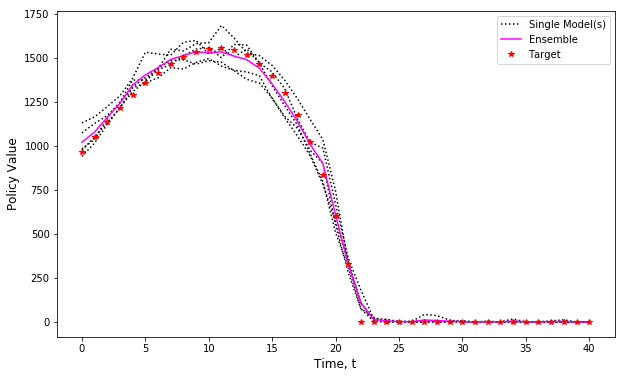

In [51]:
ensemble_plot(models = models_mse[0:N_ensembles], model_ens = ensemble_mse_5, data = data_test_sc, 
              y = targets_test, contract_display=11, display_wo_qualitative_part=True, 
              display_qualitative_part=False, data_type= '2D' )

#### Ensembles: 10, MSE (V1)

In [52]:
N_ensembles = 10

ensemble_mse_10 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mse[0:N_ensembles]), 
                                 scale = V_max,
                               LSTM_nodes= [n_output], dense_act_fct= 'tanh')

#### Ensembles: 5, MAE (V2)

In [53]:
N_ensembles = 5

ensemble_mae_5 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mae[0:N_ensembles]), 
                                scale = V_max,
                               LSTM_nodes= [n_output], dense_act_fct= 'tanh')

#### Ensembles: 10, MAE (V3)

In [54]:
N_ensembles = 10

ensemble_mae_10 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mae[0:N_ensembles]), 
                                 scale = V_max,
                               LSTM_nodes= [n_output], dense_act_fct= 'tanh')

#### Ensembles: 5, Mixed MSE and MAE (V4)

In [55]:
N_ensembles = 5

# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mae_mse_5 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, 
                                    load_weights= True, 
                                    weights_ensembles = multiple_models_get_weights(models_mse[0:3]+
                                                                                    models_mae[0:2]), 
                                    scale = V_max,
                                    LSTM_nodes= [n_output], dense_act_fct= 'tanh')


#### Ensembles: 10, MSE and MAE mixed (V5)

In [56]:
N_ensembles = 10

# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mae_mse_10 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, 
                                    load_weights= True, 
                                    weights_ensembles = multiple_models_get_weights(models_mse[0:5]+
                                                                                    models_mae[0:5]), 
                                    scale = V_max,
                                    LSTM_nodes= [n_output], dense_act_fct= 'tanh')


### 3.5.3. Statistical Analysis/ Comparisons of Models

Statistics, using Diff${}_t$ and WRE${}_t$

In [57]:
def get_early_stopping_epoch(history_dict):
    for i in range(len(history_dict)):
        print(len(history_dict[i]['loss']))
    
    return

In [58]:
len(models_mse_hist[0]['loss'])

687

In [59]:
get_early_stopping_epoch(models_mse_hist)
print('--------------')
get_early_stopping_epoch(models_mae_hist)

687
1117
986
997
861
906
825
892
574
653
--------------
583
782
760
814
853
907
851
895
876
860


In [60]:
results_statistic = create_df_model_comparison(model_single_lst=models_mse[0:2]+models_mae[2:4], 
                                x_test = data_test_sc, y_test= targets_test,  
                               model_ens_lst = [ensemble_mse_5, ensemble_mse_10, 
                                                ensemble_mae_5, ensemble_mae_10,
                                                ensemble_mae_mse_5, ensemble_mae_mse_10],
                                names_number= ['5','10','5','10',
                                               '5', '10'], 
                                names_loss= ['MSE','MSE','MAE', 'MAE', 
                                             'Mixed', 'Mixed'], 
                                names_loss_single = ['MSE']*2+['MAE']*2)

In [61]:
results_statistic[0]

,Loss,$N_{Ens}$,$\overline{e}_t$,"$pc_{0.99, |e_t|}$",$\overline{wre}_t$,"$pc_{0.99, |wre_t|}$"
Model 0,MSE,1,10.08,1527.67,3.66e-07,6.84e-06
Model 1,MSE,1,6.92,1150.01,1.46e-07,6.71e-06
Model 2,MAE,1,5.95,1240.44,-2.34e-06,4.58e-06
Model 3,MAE,1,-3.60,1174.61,-1.68e-06,4.13e-06
Ensemble 0,MSE,5,14.22,857.76,2.91e-07,5.26e-06
Ensemble 1,MSE,10,10.60,809.84,3.87e-07,6.35e-06
Ensemble 2,MAE,5,3.49,716.40,-2.08e-06,2.85e-06
Ensemble 3,MAE,10,-3.43,585.10,-2.32e-06,2.38e-06
Ensemble 4,Mixed,5,5.16,847.61,-6.54e-07,4.24e-06
Ensemble 5,Mixed,10,8.85,660.36,-8.95e-07,3.73e-06


In [64]:
with open('Prediction_TL_Model_Comparison.tex','w') as tf:
    tf.write(results_statistic[0].to_latex())

In [149]:
%run functions/visualization_functions.ipynb

Statistics, using $e_t$

In [75]:
# Relate following relative values to absolute Policy Values
interval_lst = [0,0.001, 0.005, 0.01,0.2,0.4,0.6,0.8,1] #0.9,1][0, 0.005, 0.01,0.2,0.4,0.6,0.8,1]#
PV_interval =  V_max*np.asarray(interval_lst[1:])#np.asarray([0.001, 0.005, 0.01,0.2,0.4,0.6,0.8,1])#0.9,1])
df_columns = [None]*(len(interval_lst)-1)
for i in range(1,len(interval_lst)):
    df_columns[i-1] = '{}'.format(interval_lst[i])
df = pd.DataFrame(data = None, index = None, columns = df_columns)
df.loc['PV'] = PV_interval

count_cum = [sum(targets_test.max(axis=1)< PV_interval[i]) for i in range(len(interval_lst)-1)]
count =[count_cum[0]]+[count_cum[j]- count_cum[j-1] for j in range(1,len(count_cum))]
df.loc['#'] = count


targets.max(axis=1)

df

,0.001,0.005,0.01,0.2,0.4,0.6,0.8,1
PV,847.83,4239.15,8478.3,169566.05,339132.1,508698.14,678264.19,847830.24
#,9294.00,6093.00,2906.0,10065.00,1137.0,372.00,117.00,16.00


In [76]:
sum(count)

30000

In [77]:
stat_RNN_0 = model_examine_indivual_fit(model = models_mse[0], data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic', PV_max= V_max, 
                                        interval_lst= interval_lst)
stat_RNN_0

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-1
$\overline{re}_t$,0.73,0.01,-9.21e-03,-4.59e-03,2.53e-04,7.64e-04,8.45e-04,2.85e-04
"$pc_{0.99, |re_t|}$",7.01,0.30,1.09e-01,5.16e-02,2.01e-02,2.15e-02,2.33e-02,2.11e-02


In [78]:
stat_ENS_0 = model_examine_indivual_fit(model = ensemble_mse_5, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic', 
                                        interval_lst= interval_lst)
stat_ENS_0

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-1
$\overline{re}_t$,1.27,0.01,-9.30e-04,-1.29e-03,-2.61e-04,-2.34e-04,-3.81e-04,-6.57e-04
"$pc_{0.99, |re_t|}$",14.82,0.16,5.83e-02,2.31e-02,6.63e-03,8.87e-03,1.59e-02,1.27e-02


In [84]:
with open('Prediction_TL_Model_MSE_5.tex','w') as tf:
    tf.write(stat_ENS_0.to_latex())

In [79]:
stat_ENS_1 = model_examine_indivual_fit(model = ensemble_mse_10, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic', 
                                        interval_lst= interval_lst)
stat_ENS_1

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-1
$\overline{re}_t$,1.27,5.43e-03,-5.52e-03,-2.96e-03,-8.53e-04,-5.72e-04,-4.26e-04,-9.73e-04
"$pc_{0.99, |re_t|}$",15.72,1.71e-01,4.84e-02,2.34e-02,6.68e-03,7.27e-03,8.94e-03,1.07e-02


In [85]:
with open('Prediction_TL_Model_MSE_10.tex','w') as tf:
    tf.write(stat_ENS_1.to_latex())

In [80]:
stat_ENS_2 = model_examine_indivual_fit(model = ensemble_mae_5, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic')
stat_ENS_2

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-0.9,0.9-1
$\overline{re}_t$,0.13,-9.28e-06,-3.75e-04,-8.77e-04,-1.44e-03,-2.11e-03,-1.77e-03,-2.36e-03,-9.59e-03
"$pc_{0.99, |re_t|}$",2.33,4.97e-02,2.97e-02,2.09e-02,2.20e-02,4.20e-02,1.88e-02,1.99e-02,4.67e-02


In [81]:
stat_ENS_3 = model_examine_indivual_fit(model = ensemble_mae_10, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic')
stat_ENS_3

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-0.9,0.9-1
$\overline{re}_t$,0.13,-2.00e-04,-5.26e-04,-1.16e-03,-1.70e-03,-2.31e-03,-2.08e-03,-3.63e-03,-0.01
"$pc_{0.99, |re_t|}$",2.43,2.98e-02,1.80e-02,1.57e-02,2.82e-02,4.90e-02,2.56e-02,2.70e-02,0.05


In [82]:
stat_ENS_4 = model_examine_indivual_fit(model = ensemble_mae_mse_5, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic')
stat_ENS_4

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-0.9,0.9-1
$\overline{re}_t$,0.47,3.70e-03,-3.84e-03,-2.95e-03,-8.88e-04,-8.19e-04,-7.05e-04,-1.08e-03,-5.64e-03
"$pc_{0.99, |re_t|}$",5.69,1.30e-01,4.11e-02,2.37e-02,1.54e-02,1.61e-02,8.33e-03,8.38e-03,2.25e-02


In [83]:
stat_ENS_5 = model_examine_indivual_fit(model = ensemble_mae_mse_10, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic')
stat_ENS_5

,0-0.001,0.001-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-0.9,0.9-1
$\overline{re}_t$,0.70,6.36e-03,-6.52e-04,-1.08e-03,-8.49e-04,-1.17e-03,-1.08e-03,-1.07e-03,-6.70e-03
"$pc_{0.99, |re_t|}$",8.45,9.17e-02,3.06e-02,1.76e-02,1.44e-02,2.12e-02,1.04e-02,9.94e-03,2.44e-02


In [ ]:
# Examine dist of WRE and AE over time
plt.boxplot(results_statistic[2][2])#[:,:-2])
plt.tight_layout()
plt.show()

plt.boxplot(results_statistic[1][2], notch=False)
plt.tight_layout()
plt.show()

In [ ]:
# Examine Relation between WRE and Error (Diff)
wre = results_statistic[2][2].flatten()
diff = results_statistic[1][2][:,:-2].flatten()
index = (wre != wre.min())
plt.scatter((diff[index]), (wre[index]))
plt.xlabel('Error (Difference)')
plt.ylabel('WRE')
plt.show()

# Examine Relation between WRE and Policy Values
plt.scatter((targets_test[:,:-2].flatten()[index]), (wre[index]))
plt.xlabel('Target PV')
plt.ylabel('WRE')
plt.show()

## 3.6. Concluding Analysis - Accuracy of Prediction/ Section 3

Keeping the main application in mind (agglomeration), we're especially interested in the model's accuracy from a cumulative point of view.

### 3.6.1. Visualization of Accuracy

In [92]:
%run functions/visualization_functions.ipynb

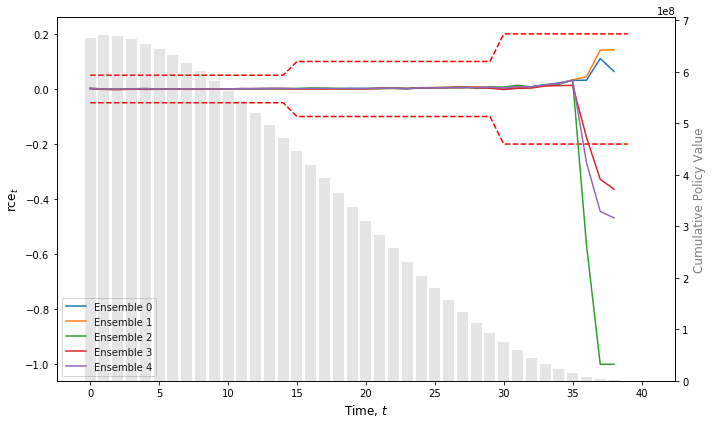

In [119]:
acc_stat = plot_accuracy_cum(model_lst = [ensemble_mse_5, ensemble_mse_10, 
                                            ensemble_mae_5,# ensemble_mae_10,
                                            ensemble_mae_mse_5, ensemble_mae_mse_10], 
                              x = [data_test_sc], y = targets_test)

In [ ]:
# Numeric values of the plot above
acc_stat

In [ ]:
# number of policies with non-zero reserve
# Note: Some of the 30,000 Policies start at t=0, 
# resulting in less than 30,000 policies with non-zero reserve at t=0
(targets_test != 0).sum(axis=0)

# Section 4 - Agglomeration of Contracts

In [86]:
# Ensemble to integrate in Clustering procedure, Choose EP with 5 Sub-Models
model_supervision_clustering = ensemble_mse_5
optimizer_cl = Adadelta(lr = 0.2, decay = 0.0)#'adam' #
# Path
wd_cluster = cd+r'\ipynb_Checkpoints\Grouping'

In [87]:
n_timesteps, n_features, n_output = dur_max+1,n_in, dur_max+1
#INPUT_ens = Input(shape=(n_timesteps,n_features), name = 'Input')
N_epochs_clustering = 30000
es_patience_clustering = 100
load_agg_model = True

In [88]:
%run functions/clustering.ipynb
%run functions/statistical_analysis_functions.ipynb

## 4.1. 100 Clusters

Baseline (K-Means)

In [89]:
N_clusters = 100

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters)):
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_100 = pickle.load(input)
else:
    # perform clustering
    kMeans_100 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=100, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_100, output, pickle.HIGHEST_PROTOCOL)
    
# Number of Contracts per Cluster
count_kMeans = kmeans_counts(kMeans_100.labels_,N_clusters)

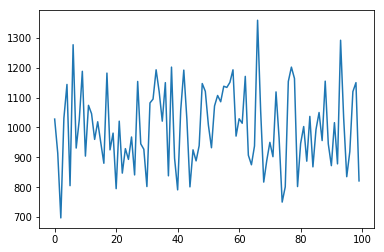

In [102]:
# Check distribution of members per cluster
plt.plot(count_kMeans)
plt.show()

Use ANN for Clustering

In [90]:
## Data
N_clusters = 100

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_100 = []
targets_lst_cluster_100 = []
for i in range(N_clusters):
    index = kMeans_100.labels_ == i
    data_lst_cluster_100.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_100.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [91]:
## Apply ANN
N_clusters = 100

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_100 = pickle.load(input)
else:
    # perform agglomeration by ANN
    cluster_analysis_100 = cluster_ann_test(y_lst = targets_lst_cluster_100, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_100.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_100.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_100, output, pickle.HIGHEST_PROTOCOL)

Note: cluster_analysis contrains 4 kinds of information

0) Matrix of representative contracts
1) Matrix of policy values of representative contracts
2) List of weights to potentially restore the model of an individual cluster
3) Array of times required to compute the agglomeration

In [92]:
cluster_analysis_100[3].sum()/3600

6.779547222222222

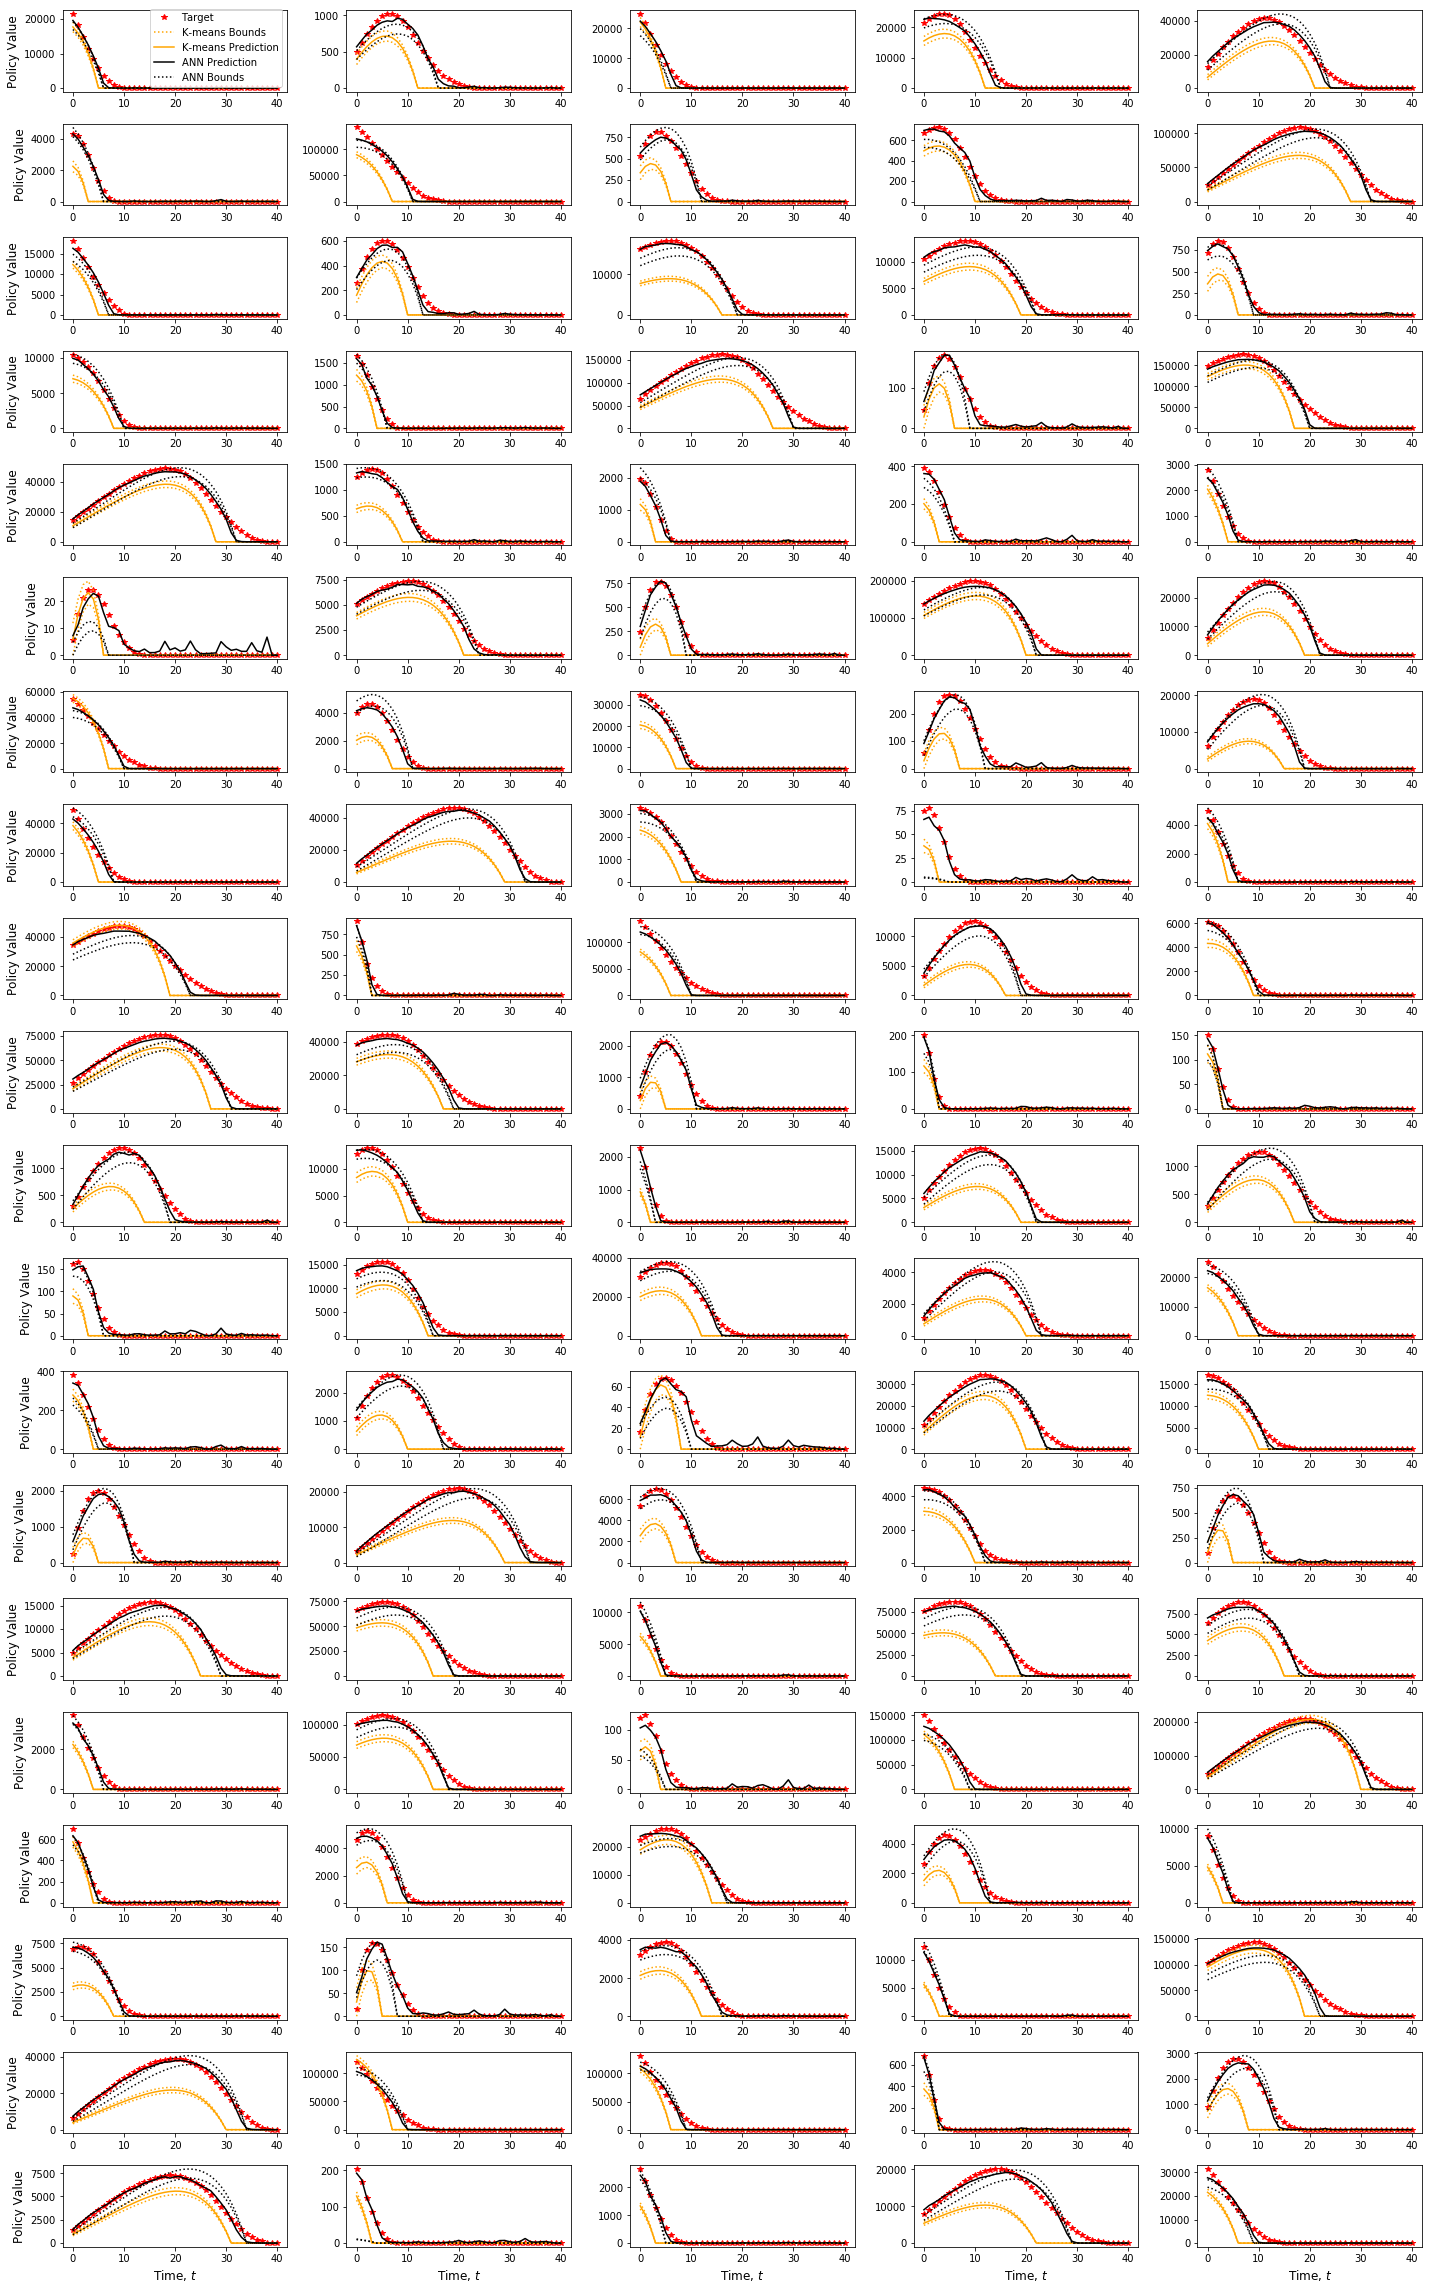

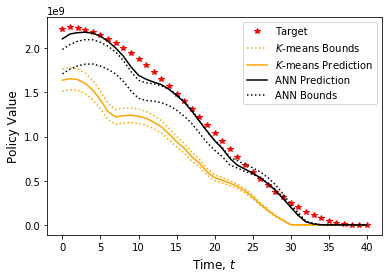

In [93]:
analyze_agglomeration(baseline = kMeans_100, y = targets_lst_cluster_100, Max_min=Max_min,
                      include_ann= True, ann_prediction= cluster_analysis_100[1], 
                      #ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_100[0], individual_clusters=True,
                      figsize = (20,32), insurance_type= 'termlife')

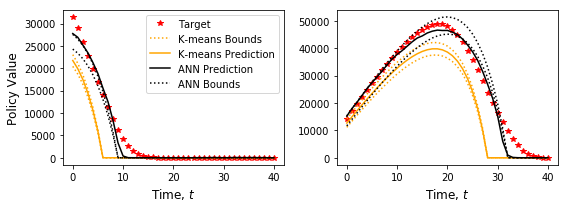

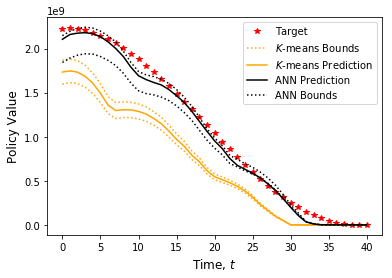

In [95]:
# Selection of Clusters to illustrate problems for low policy values
analyze_agglomeration(baseline = kMeans_100, y = targets, Max_min=Max_min, interest_rate= int_rate,
                      include_ann= True, ann_prediction= cluster_analysis_100[1], 
                      ann_representatives= cluster_analysis_100[0], individual_clusters=True, 
                      n_columns=2, figsize= (8,3),
                     option_plot_selection = [99, 20])


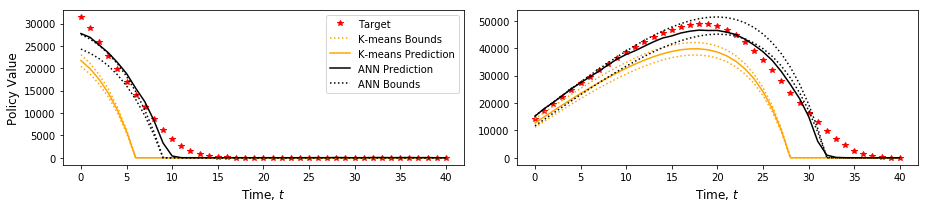

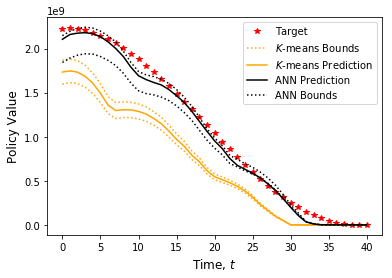

In [96]:
# Selection of Clusters to illustrate problems for low policy values
analyze_agglomeration(baseline = kMeans_100, y = targets, Max_min=Max_min, interest_rate= int_rate,
                      include_ann= True, ann_prediction= cluster_analysis_100[1], 
                      ann_representatives= cluster_analysis_100[0], individual_clusters=True, 
                      n_columns=2, figsize= (13,3),
                     option_plot_selection = [99, 20])


,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.54,-3.78e+08
ANN Prediction,-0.20,-5.50e+07
ANN Bounds (up),-0.17,-1.25e+07
ANN Bounds (low),-0.27,-1.46e+08


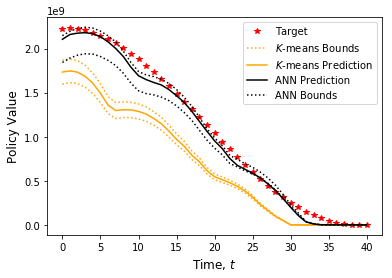

In [153]:
stat_100 = analyze_agglomeration(baseline = kMeans_100, y = targets, Max_min=Max_min,
                      include_ann= True, ann_prediction= cluster_analysis_100[1], 
                                    # ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_100[0], individual_clusters=True,
                      option='statistic', option_cluster_fit=False, interest_rate= int_rate,
                      figsize = (20,4), insurance_type= 'termlife')

stat_100[0]#.style.set_properties(subset=[r'$CL_{0.99,|re{}_t|}$'], **{'width': '60px'})

In [154]:
with open('Grouping_TL_K100.tex','w') as tf:
    tf.write(stat_100[0].to_latex())

## 4.2. 50 Clusters

Baseline (K-Means)

In [98]:
N_clusters = 50

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters)):
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_50 = pickle.load(input)
else:
    # perform clustering
    kMeans_50 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=100, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_50, output, pickle.HIGHEST_PROTOCOL)
    
# Number of Contracts per Cluster
count_kMeans = kmeans_counts(kMeans_50.labels_,N_clusters)

Use ANN

In [99]:
## Data
N_clusters = 50

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_50= []
targets_lst_cluster_50 = []
for i in range(N_clusters):
    index = kMeans_50.labels_ == i
    data_lst_cluster_50.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_50.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [100]:
## Apply ANN
N_clusters = 50

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_50 = pickle.load(input)
else:
    # perform agglomeration by ANN # Check if N_ensemble matches supervision model
    cluster_analysis_50 = cluster_ann_test(y_lst = targets_lst_cluster_50, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_50.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_50.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_50, output, pickle.HIGHEST_PROTOCOL)

In [101]:
cluster_analysis_50[3].sum()/3600

3.7292416666666672

In [102]:
%run functions/clustering.ipynb

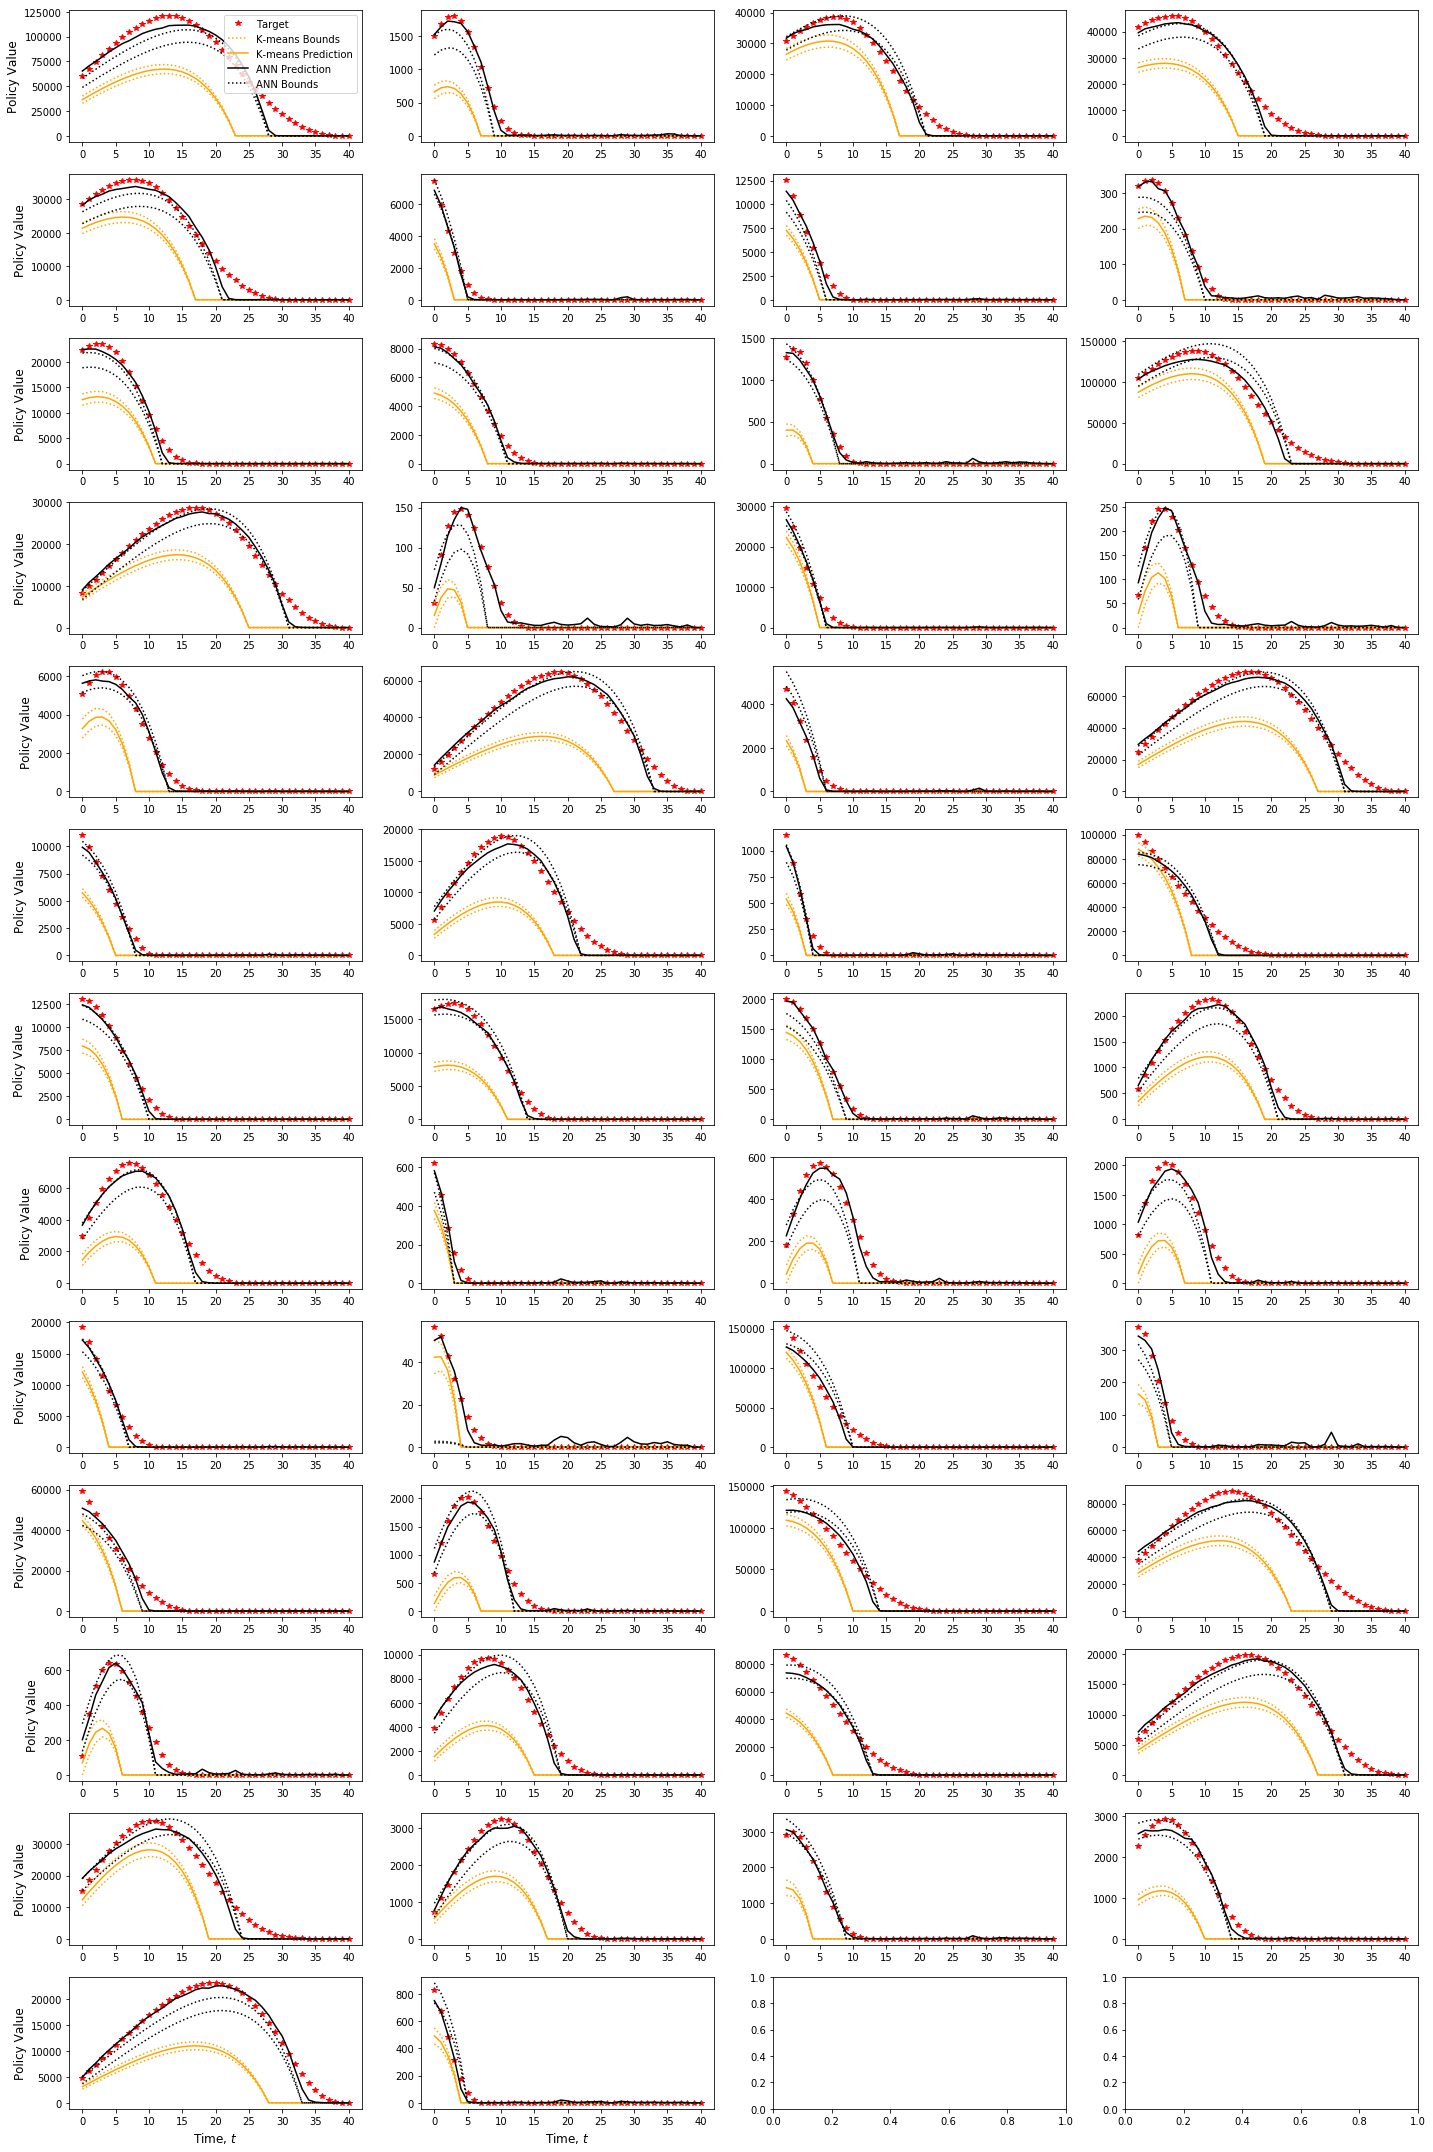

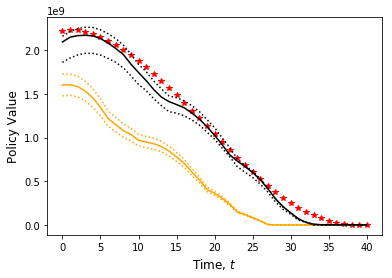

In [103]:
# Selection of Clusters to illustrate problems for low policy values
analyze_agglomeration(baseline = kMeans_50, y = targets, Max_min=Max_min, interest_rate= int_rate,
                      include_ann= True, ann_prediction= cluster_analysis_50[1], 
                      ann_representatives= cluster_analysis_50[0], individual_clusters=True, 
                      n_columns=4, option_header= False, option_legend=False)


,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.67,-5.22e+08
ANN Prediction,-0.23,-6.22e+07
ANN Bounds (up),-0.21,-1.11e+07
ANN Bounds (low),-0.31,-1.45e+08


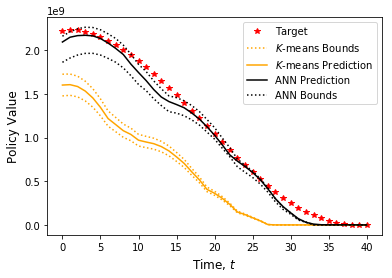

In [152]:
stat_50 = analyze_agglomeration(baseline = kMeans_50, y = targets, Max_min=Max_min,
                      include_ann= True, ann_prediction= cluster_analysis_50[1], 
                                    # ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_50[0], individual_clusters=True,
                      option='statistic', option_cluster_fit=False, interest_rate= int_rate,
                      figsize = (20,4), insurance_type= 'termlife')

stat_50[0]

In [155]:
with open('Grouping_TL_K50.tex','w') as tf:
    tf.write(stat_50[0].to_latex())

## 4.3. 25 Clusters

Baseline

In [105]:
N_clusters = 25

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters)):
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_25 = pickle.load(input)
else:
    # perform clustering
    kMeans_25 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=100, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_25, output, pickle.HIGHEST_PROTOCOL)
    
# Number of Contracts per Cluster
count_kMeans = kmeans_counts(kMeans_25.labels_,N_clusters)

Use ANN

In [106]:
## Data
N_clusters = 25

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_25 = []
targets_lst_cluster_25 = []
for i in range(N_clusters):
    index = kMeans_25.labels_ == i
    data_lst_cluster_25.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_25.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [107]:
## Apply ANN
N_clusters = 25

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_25 = pickle.load(input)
else:
    # perform agglomeration by ANN # Check if N_ensemble matches supervision model
    cluster_analysis_25 = cluster_ann_test(y_lst = targets_lst_cluster_25, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_25.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_25.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_25, output, pickle.HIGHEST_PROTOCOL)

In [108]:
cluster_analysis_25[3].sum()/3600

1.2135805555555557

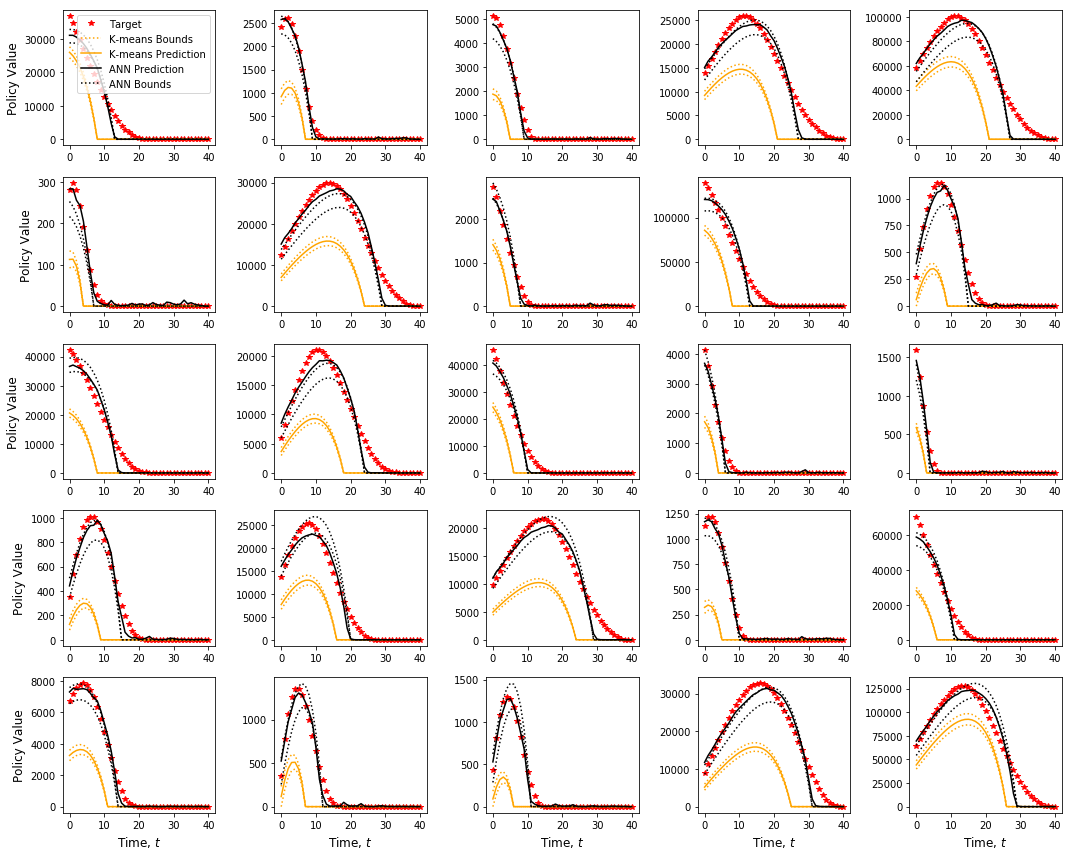

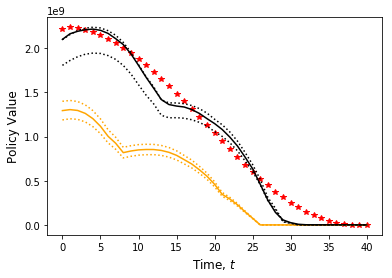

In [109]:
# Selection of Clusters to illustrate problems for low policy values
analyze_agglomeration(baseline = kMeans_25, y = targets, Max_min=Max_min, interest_rate= int_rate,
                      include_ann= True, ann_prediction= cluster_analysis_25[1], 
                      ann_representatives= cluster_analysis_25[0], individual_clusters=True, 
                      n_columns=5, figsize= (15,12),
                      option_header= False, option_legend=False)


,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.69,-5.78e+08
ANN Prediction,-0.25,-4.49e+07
ANN Bounds (up),-0.25,-2.37e+07
ANN Bounds (low),-0.34,-1.55e+08


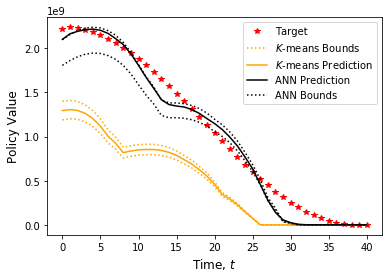

In [151]:
stat_25 = analyze_agglomeration(baseline = kMeans_25, y = targets, Max_min=Max_min,
                      include_ann= True, ann_prediction= cluster_analysis_25[1], 
                                    # ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_25[0], individual_clusters=True,
                      option='statistic', option_cluster_fit=False, interest_rate= int_rate,
                      figsize = (20,4), insurance_type= 'termlife')

stat_25[0]

In [156]:
with open('Grouping_TL_K25.tex','w') as tf:
    tf.write(stat_25[0].to_latex())

## 4.4. 10 Clusters

In [140]:
%run functions/clustering.ipynb
%run functions/rnn_functions.ipynb
%run Data/data_prep_General.ipynb
%run functions/visualization_functions.ipynb

Baseline

In [111]:
## Baseline, Parameters
N_clusters = 10

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters)):
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_10 = pickle.load(input)
else:
    # perform clustering
    kMeans_10 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=100, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_10, output, pickle.HIGHEST_PROTOCOL)

Use ANN

In [112]:
## Data
N_clusters = 10

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_10 = []
targets_lst_cluster_10 = []
for i in range(N_clusters):
    index = kMeans_10.labels_ == i
    data_lst_cluster_10.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_10.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [113]:
## Apply ANN
N_clusters = 10

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_10 = pickle.load(input)
else:
    cluster_analysis_10 = cluster_ann_test(y_lst = targets_lst_cluster_10, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 3,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_10.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_10.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    
    
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_10, output, pickle.HIGHEST_PROTOCOL)

In [114]:
cluster_analysis_10[3].sum()/3600


0.40526666666666666

In [115]:
for i in range(10):
    print(len(cluster_analysis_10[-1][i]['loss']))

6464
3207
10000
10000
10000
10000
10000
10000
10000
5568


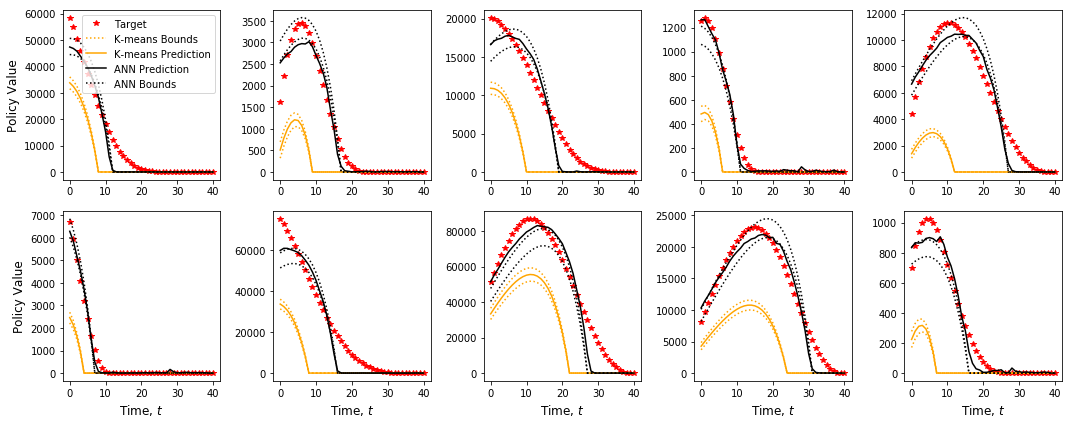

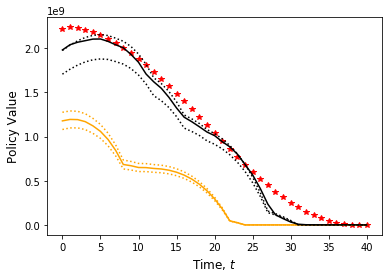

In [146]:
# Selection of Clusters to illustrate problems for low policy values
analyze_agglomeration(baseline = kMeans_10, y = targets, Max_min=Max_min, interest_rate= int_rate,
                      include_ann= True, ann_prediction= cluster_analysis_10[1], 
                      ann_representatives= cluster_analysis_10[0], individual_clusters=True, 
                      n_columns=5, figsize=(15, 6),
                     option_header= False, option_legend= False)


In [123]:
#visualize_representatives_km_ann(km_rep = kMeans_10.cluster_centers_, ann_rep = np.tanh(cluster_analysis_10[0]))

In [135]:
len(cluster_analysis_10[0][0])

5

,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.77,-6.73e+08
ANN Prediction,-0.30,-9.05e+07
ANN Bounds (up),-0.30,-6.72e+07
ANN Bounds (low),-0.39,-1.92e+08


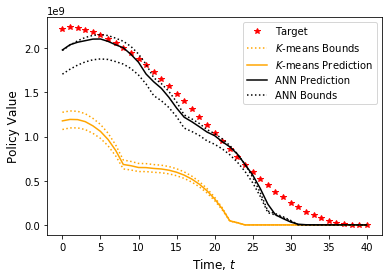

In [150]:
stat_10 = analyze_agglomeration(baseline = kMeans_10, y = targets, Max_min=Max_min,
                      include_ann= True, ann_prediction= cluster_analysis_10[1], 
                                    # ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_10[0], individual_clusters=True,
                      option='statistic', option_cluster_fit=False, interest_rate= int_rate,
                      figsize = (20,4), insurance_type= 'termlife')

stat_10[0]

In [157]:
with open('Grouping_TL_K10.tex','w') as tf:
    tf.write(stat_10[0].to_latex())

In [ ]:
# Table for runtimes of clustering models
runtimes = np.asarray([cluster_analysis_100[3].sum()/60,cluster_analysis_50[3].sum()/60,
                     cluster_analysis_25[3].sum()/60, cluster_analysis_10[3].sum()/60], dtype = 'int')
df_agglom_runtimes = pd.DataFrame(data = None, index = None, columns = [r'$K$','','$100$','$50$', '$25$', '$10$'])
df_agglom_runtimes.loc[''] = ['$\text{Runtime [min]}$',r'$\tilde{P}_\mathcal{N}$',int(cluster_analysis_100[3].sum()/60),int(cluster_analysis_50[3].sum()/60),
                     int(cluster_analysis_25[3].sum()/60), int(cluster_analysis_10[3].sum()/60)]

In [ ]:
# Check Runtime of K-Means
runtimes_km = [None]*4
j=0
for i in [100,50,25,10]:
    t_km_start = time.time()
    cluster.MiniBatchKMeans(n_clusters=i, batch_size=100, verbose =0).fit(data_sc)
    runtimes_km[j]= time.time()-t_km_start
    j+=1

In [ ]:
df_agglom_runtimes.loc[' '] = ['',r'$\tilde{P}_0$',runtimes_km[0]/60,runtimes_km[1]/60,runtimes_km[2]/60,runtimes_km[3]/60]
df_agglom_runtimes